In [1]:
# TODO Save trial.user_attr range of parameters
# TODO For neuronal network visualizate by epoch
# TODO Summary protocol

In [3]:
from utilsOptuna import remove_study_from_storage

remove_study_from_storage('sqlite:///optuna_DL_exercise.db', 'MDL_fcnn_pca_embeddings1')

Study 'MDL_fcnn_pca_embeddings1' deleted successfully


In [6]:
from utilsOptuna import info_studies_from_storage

storage = 'sqlite:///optuna_DL_exercise.db'
print(f"Storage: {storage}")
info_studies_from_storage(storage)

Storage: sqlite:///optuna_DL_exercise.db


,study_name,best_score,description
0,MDL_fcnn_pca_embeddings1,0.643243,FCNN with Progressive Compression Architecture...
1,MDL_fcnn_shallow_metadata1,0.794613,Shallow FCNN using metadata


In [10]:
import optuna

storage = 'sqlite:///optuna_DL_exercise.db'
study_name = 'MDL_fcnn_pca_embeddings1'
study = optuna.load_study(
    study_name = study_name,
    storage = storage
)

In [ ]:
# info save in study
print(study.user_attrs)
# info save in trial
print(study.best_trial)

{'comments': 'FCNN with Progressive Compression Architecture for embeddings', 'config_file': 'MDL_fcnn_pca_embeddings1.pkl', 'script': './MDL_fcnn_pca_embeddings1.py'}
FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6432432432432432], datetime_start=datetime.datetime(2025, 10, 21, 12, 34, 53, 153071), datetime_complete=datetime.datetime(2025, 10, 21, 12, 35, 3, 629346), params={'batch_size': 3, 'dropout_rate': 0.9556428757689246, 'lr': 0.0785148544202769}, user_attrs={'fixed_params': {'data_loader': {}, 'model': {'input_size': 384, 'num_classes': 2}, 'optimizer': {}, 'criterion': {}}, 'num_epochs': 10, 'params': {'data_loader': {'batch_size': 8}, 'model': {'dropout_rate': 0.9556428757689246}, 'optimizer': {'lr': 0.0785148544202769}, 'criterion': {}}, 'run': 'base_run', 'score': 'f1_score', 'train_results': {'loss': [286.07913675904274, 94.89378356933594, 90.08631724119186, 87.88050413131714, 88.43072575330734, 88.82260143756866, 87.53311496973038, 87.82226186990738, 87.06729

In [10]:
from utilsOptuna import info_runs_from_study

# get info for runs of a study
print(f"Storage: {storage}")
print(f"Study: {study_name}")
#info_runs_from_study(study.trials, extended=True)
info_runs_from_study(study.trials)


Storage: sqlite:///optuna_DL_exercise.db
Study: fcnn_pca_embeddings1


,run,num_trials,completed_trials,best_score
0,base_run,10,9,0.705882
1,extension1_run,10,5,0.678322
2,extension2_run,10,5,0.643357


In [5]:
from utilsOptuna import optuna_results

# output for best_trial
print(f"Storage: {storage}")
print(f"Study: {study_name}")
optuna_results(study)

Storage: sqlite:///optuna_DL_exercise.db
Study: fcnn_pca_embeddings1
Best trial:
  Value:  0.7058823529411765
  Params: 
			Value
    batch_size:	2.00000
    dropout_rate:	0.37382
    lr:	0.01876


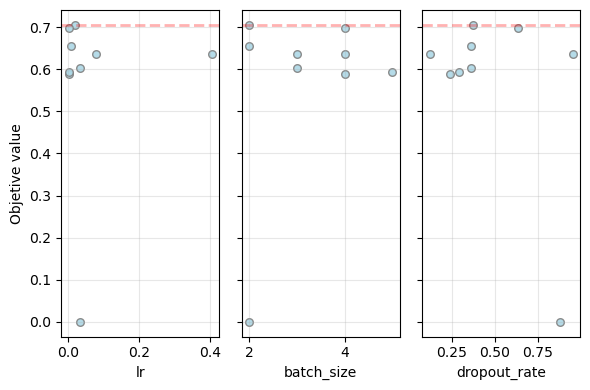

In [6]:
from utilsOptuna import plot_slice

# TODO Custom plot_slice adapt log variables to axis scale
# TODO Custom plot_slice select highest trials
# TODO Select run
plot_slice(study) # Slice plot param vs objetiveValue

/tmp/ipykernel_106169/3579258984.py:5: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_contour(study, params=['batch_size', 'dropout_rate']) # 2D contour plot


<Axes: title={'center': 'Contour Plot'}, xlabel='batch_size', ylabel='dropout_rate'>

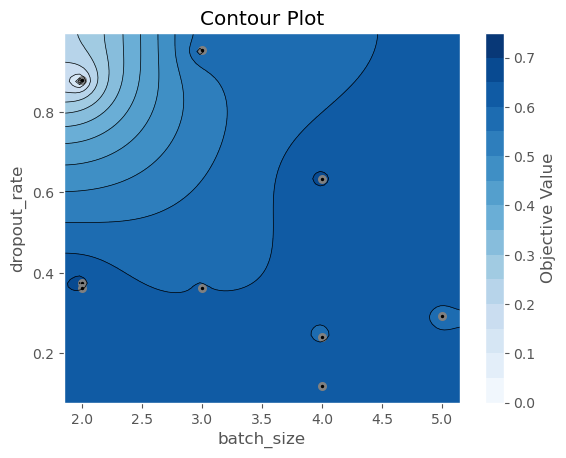

In [8]:
import optuna

# TODO plot optimized hyperparameters
# TODO Make custom plot_contour. Highlight best result.
optuna.visualization.matplotlib.plot_contour(study, params=['batch_size', 'dropout_rate']) # 2D contour plot


In [7]:
from utilsOptuna import plot_train_nn

trial = study.best_trial
trial
#plot_train_nn(trial, 'f1_score')

FrozenTrial(number=1, state=TrialState.COMPLETE, values=[0.6432432432432432], datetime_start=datetime.datetime(2025, 10, 21, 11, 36, 4, 147034), datetime_complete=datetime.datetime(2025, 10, 21, 11, 36, 15, 198570), params={'batch_size': 3, 'dropout_rate': 0.9556428757689246, 'lr': 0.0785148544202769}, user_attrs={'fixed_params': {'data_loader': {}, 'model': {'input_size': 384, 'num_classes': 2}, 'optimizer': {}, 'criterion': {}}, 'num_epochs': 10, 'params': {'data_loader': {'batch_size': 8}, 'model': {'dropout_rate': 0.9556428757689246}, 'optimizer': {'lr': 0.0785148544202769}, 'criterion': {}}, 'run': 'base_run', 'score': 'f1_score', 'train_results': {'loss': [286.07913675904274, 94.89378356933594, 90.08631759881973, 87.8805039525032, 88.43072611093521, 88.82273709774017, 87.53311491012573, 87.82226198911667, 87.06729379296303, 88.34002780914307], 'sensitivity': [0.5494736842105263, 0.21263157894736842, 0.3873684210526316, 0.17684210526315788, 0.4126315789473684, 0.35578947368421054,

In [ ]:
# TODO How to calculate importance features. Is strange? Most importance to max_depth and n_estimators?
#optuna.visualization.matplotlib.plot_param_importances(study,evaluator=optuna.importance.FanovaImportanceEvaluator())